In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
df = pd.read_csv(r'heart.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [15]:
df.drop(columns=['target']).boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.title('boxplot')

Text(0.5, 1.0, 'boxplot')

In [16]:
for kolom in ['chol', 'trestbps']:
    Q1 = df[kolom].quantile(0.25)
    Q3 = df[kolom].quantile(0.75)
    IQR = Q3 - Q1
    batas_atas = Q3 + 1.5 * IQR
    batas_bawah = Q1 - 1.5 * IQR
    outlier = df[(df[kolom] > batas_atas) | (df[kolom] < batas_bawah)]
    print(f'{kolom}: {len(outlier)} ourlier ({len(outlier)/len(df)*100:.1f})')


chol: 16 ourlier (1.6)
trestbps: 30 ourlier (2.9)


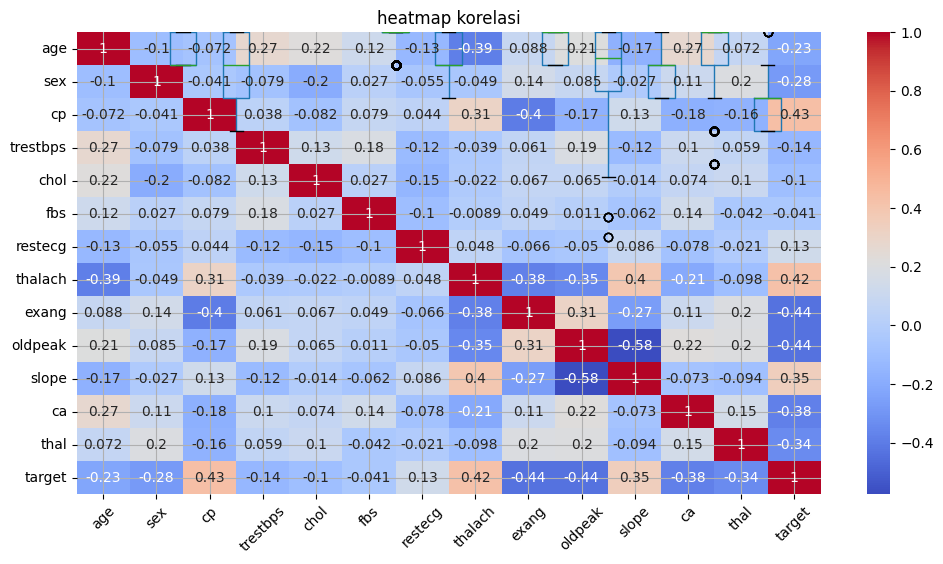

In [17]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('heatmap korelasi')
plt.show()

In [18]:
df = df.drop(columns=['chol', 'fbs', 'restecg', 'trestbps'])
print(df.duplicated().sum())

723


In [20]:
for col in ['age', 'thalach', 'oldpeak']:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

    
x = df.drop(columns=['target'])
y = df['target']

split = int(0.8 * len(df))
x_train = x.iloc[:split].values
x_test  = x.iloc[split:].values
y_train = y.iloc[:split].values
y_test  = y.iloc[split:].values

print(f'Train: {len(x_train)} data')
print(f'Test : {len(x_test)} data')
print(df.head())

Train: 820 data
Test : 205 data
        age  sex  cp   thalach  exang   oldpeak  slope  ca  thal  target
0  0.479167    1   0  0.740458      0  0.161290      2   2     3       0
1  0.500000    1   0  0.641221      1  0.500000      0   0     3       0
2  0.854167    1   0  0.412214      1  0.419355      0   0     3       0
3  0.666667    1   0  0.687023      0  0.000000      2   1     3       0
4  0.687500    0   0  0.267176      0  0.306452      1   3     2       0
